In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf

from pathlib import Path

In [4]:
metadata_path = Path("../data/metadata/ravdess_metadata.csv")

df = pd.read_csv(metadata_path)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1440, 9)


,file_path,modality,vocal_channel,emotion_id,emotion,intensity,statement,repetition,actor_id
0,data/raw/RAVDESS/Actor_01/03-01-01-01-01-01-01...,3,1,1,neutral,1,1,1,1
1,data/raw/RAVDESS/Actor_01/03-01-01-01-01-02-01...,3,1,1,neutral,1,1,2,1
2,data/raw/RAVDESS/Actor_01/03-01-01-01-02-01-01...,3,1,1,neutral,1,2,1,1
3,data/raw/RAVDESS/Actor_01/03-01-01-01-02-02-01...,3,1,1,neutral,1,2,2,1
4,data/raw/RAVDESS/Actor_01/03-01-02-01-01-01-01...,3,1,2,calm,1,1,1,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   file_path      1440 non-null   str  
 1   modality       1440 non-null   int64
 2   vocal_channel  1440 non-null   int64
 3   emotion_id     1440 non-null   int64
 4   emotion        1440 non-null   str  
 5   intensity      1440 non-null   int64
 6   statement      1440 non-null   int64
 7   repetition     1440 non-null   int64
 8   actor_id       1440 non-null   int64
dtypes: int64(7), str(2)
memory usage: 101.4 KB


In [6]:
df.describe(include="all")

,file_path,modality,vocal_channel,emotion_id,emotion,intensity,statement,repetition,actor_id
count,1440,1440.0,1440.0,1440.000000,1440,1440.000000,1440.000000,1440.000000,1440.000000
unique,1440,NaN,NaN,NaN,8,NaN,NaN,NaN,NaN
top,data/raw/RAVDESS/Actor_01/03-01-01-01-01-01-01...,NaN,NaN,NaN,calm,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,192,NaN,NaN,NaN,NaN
mean,NaN,3.0,1.0,4.733333,NaN,1.466667,1.500000,1.500000,12.500000
std,NaN,0.0,0.0,2.175356,NaN,0.499061,0.500174,0.500174,6.924591
min,NaN,3.0,1.0,1.000000,NaN,1.000000,1.000000,1.000000,1.000000
25%,NaN,3.0,1.0,3.000000,NaN,1.000000,1.000000,1.000000,6.750000
50%,NaN,3.0,1.0,5.000000,NaN,1.000000,1.500000,1.500000,12.500000
75%,NaN,3.0,1.0,7.000000,NaN,2.000000,2.000000,2.000000,18.250000


In [7]:
df.isnull().sum()

file_path        0
modality         0
vocal_channel    0
emotion_id       0
emotion          0
intensity        0
statement        0
repetition       0
actor_id         0
dtype: int64

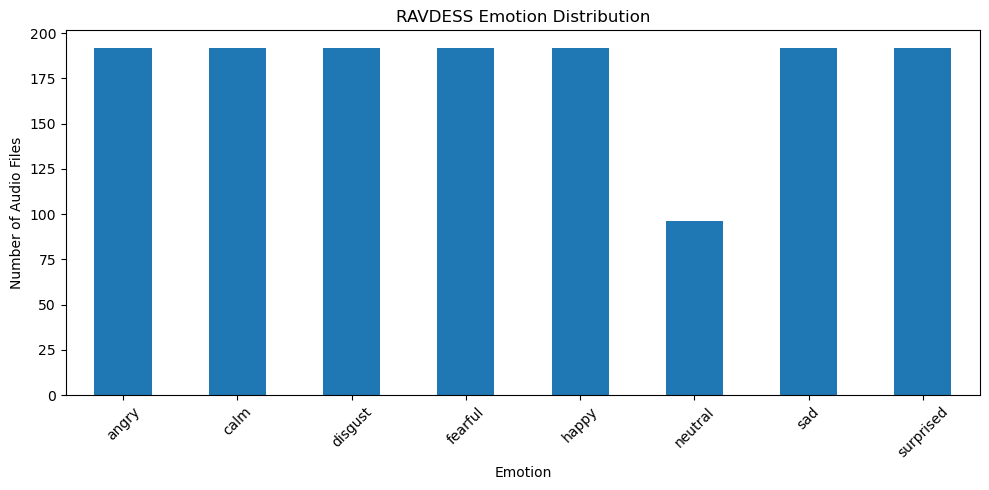

In [8]:
emotion_counts = df["emotion"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
emotion_counts.plot(kind="bar")

plt.title("RAVDESS Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Audio Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

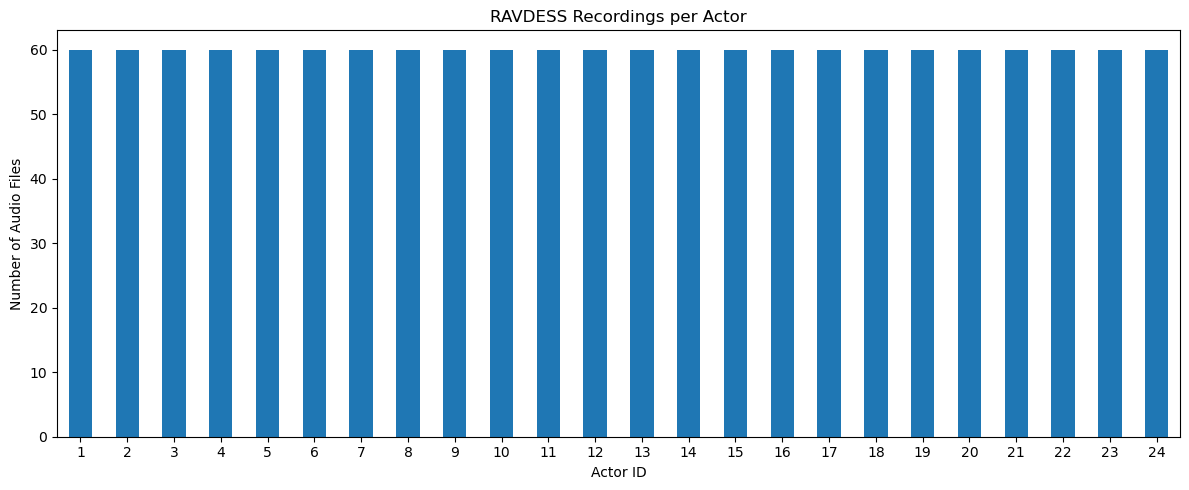

In [9]:
actor_counts = df["actor_id"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
actor_counts.plot(kind="bar")

plt.title("RAVDESS Recordings per Actor")
plt.xlabel("Actor ID")
plt.ylabel("Number of Audio Files")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
audio_path = "/Users/spoorthy/Documents/Projects/speech-emotion-recognition/data/raw/RAVDESS/Actor_01/03-01-01-01-01-01-01.wav"

print("Audio path:", audio_path)

Audio path: /Users/spoorthy/Documents/Projects/speech-emotion-recognition/data/raw/RAVDESS/Actor_01/03-01-01-01-01-01-01.wav


In [16]:
audio, sr = librosa.load(audio_path, sr=None)

print("Sample rate:", sr)
print("Number of samples:", len(audio))
print("Duration:", len(audio) / sr, "seconds")

Sample rate: 16000
Number of samples: 52853
Duration: 3.3033125 seconds


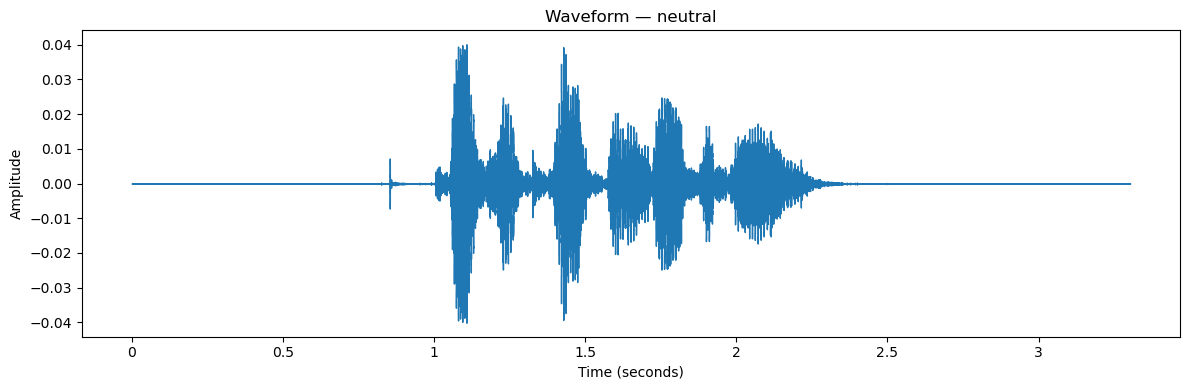

In [17]:
plt.figure(figsize=(12, 4))

librosa.display.waveshow(audio, sr=sr)

plt.title(f"Waveform — {df.iloc[0]['emotion']}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

In [18]:
mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_fft=1024,
    hop_length=256,
    n_mels=128
)

mel_db = librosa.power_to_db(mel, ref=np.max)

In [19]:
import numpy as np

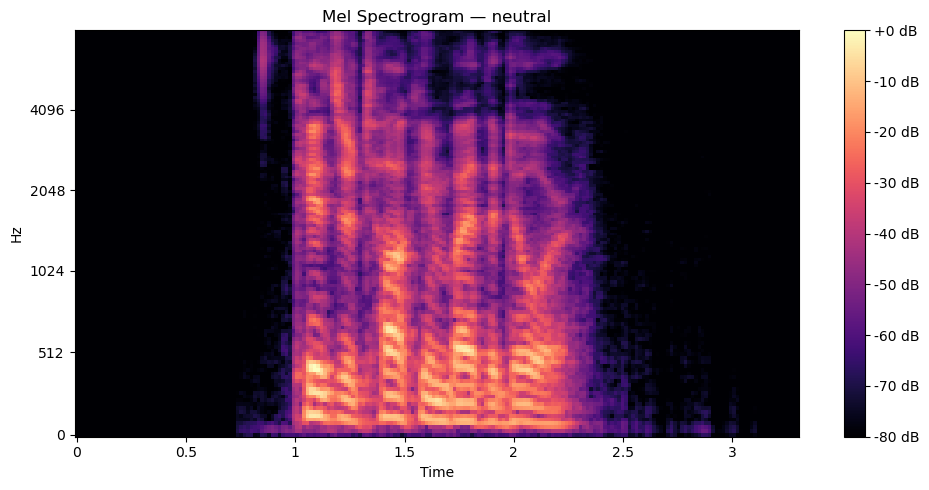

In [20]:
plt.figure(figsize=(10, 5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=256,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title(f"Mel Spectrogram — {df.iloc[0]['emotion']}")
plt.tight_layout()
plt.show()